In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from google.colab import files
uploaded=files.upload()

Saving customer_shopping_data.csv to customer_shopping_data.csv


In [4]:
df=pd.read_csv('customer_shopping_data.csv')

In [5]:
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


In [7]:
df.describe()

,age,quantity,price
count,99457.000000,99457.000000,99457.000000
mean,43.427089,3.003429,689.256321
std,14.990054,1.413025,941.184567
min,18.000000,1.000000,5.230000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,69.000000,5.000000,5250.000000


DATA CLEANING

In [8]:
#missing values
df.isnull().sum()

,0
invoice_no,0
customer_id,0
gender,0
age,0
category,0
quantity,0
price,0
payment_method,0
invoice_date,0
shopping_mall,0


In [9]:
#removing missing values
df.dropna(inplace=True)

In [10]:
#duplicate values
df.duplicated().sum()

np.int64(0)

In [11]:
#removing duplicates
df.drop_duplicates(inplace=True)

In [12]:
df.columns

Index(['invoice_no', 'customer_id', 'gender', 'age', 'category', 'quantity',
       'price', 'payment_method', 'invoice_date', 'shopping_mall'],
      dtype='object')

DATE CONVERSION

In [15]:
df['invoice_date']=pd.to_datetime(df['invoice_date'],errors='coerce')


In [16]:
df.dtypes

,0
invoice_no,object
customer_id,object
gender,object
age,int64
category,object
quantity,int64
price,float64
payment_method,object
invoice_date,datetime64[ns]
shopping_mall,object


TOTAL SALES ANALYSIS

In [17]:
print("Total sales:",df['price'].sum())

Total sales: 68551365.91


Category-wise Sales Bar Chart

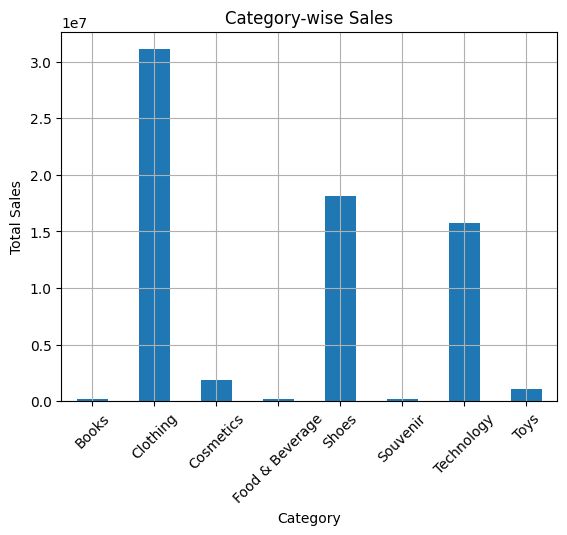

In [25]:
category_sales=df.groupby('category')['price'].sum()
category_sales.plot(kind='bar')
plt.title('Category-wise Sales')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

This barchart shows the sales performance across different product categories.It helps identify the categories that generate the highest revenue.

Monthly Sales Trend Linechart

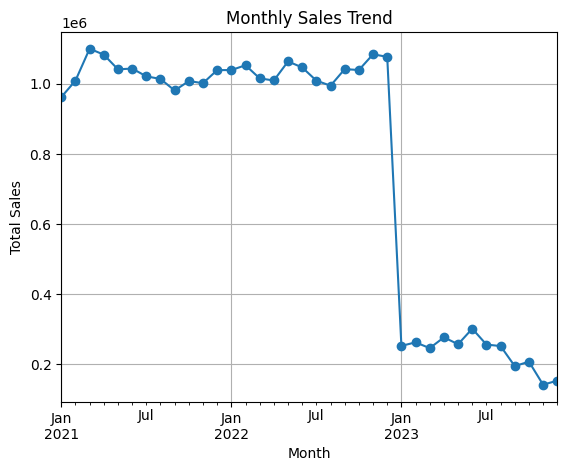

In [26]:
df['invoice_date']=pd.to_datetime(df['invoice_date'],dayfirst=True,errors='coerce')
monthly_sales=df.groupby(df['invoice_date'].dt.to_period('M'))['price'].sum()
monthly_sales.plot(kind='line',marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

This Linechart represents the monthly sales trend over time.It helps analyze sales growth,seasonal patterns,and overall business performance.

Gender-Wise Sales Piechart

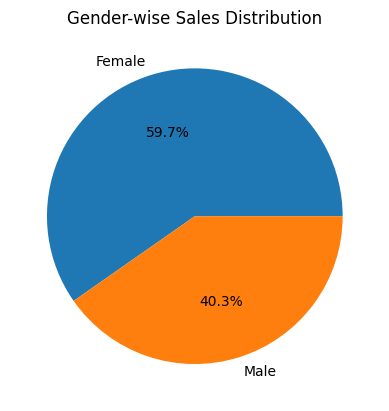

In [27]:
gender_sales=df.groupby('gender')['price'].sum()
gender_sales.plot(kind='pie',autopct='%1.1f%%')
plt.title("Gender-wise Sales Distribution")
plt.ylabel("")
plt.show()

The pie chart shows the percentage contribution of sales by gender.It helps understand customer purchasing behaviour and sales distribution

Automated Report

In [28]:
print("----- AUTOMATED REPORT -----")
print("Total Records:", len(df))
print("Total Sales:", df['price'].sum())
print("Average Sales:", df['price'].mean())
print("Maximum Sale:", df['price'].max())
print("Minimum Sale:", df['price'].min())

----- AUTOMATED REPORT -----
Total Records: 99457
Total Sales: 68551365.91
Average Sales: 689.2563209226097
Maximum Sale: 5250.0
Minimum Sale: 5.23


The automated report provides a quick summary of the dataset, including total records, total sales, average sales, and sales statistics. This reduces manual effort and improves reporting efficiency.

Save Cleaned Dataset


In [29]:
df.to_csv('cleaned_customer_shopping_data.csv',index=False)

The cleaned dataset was exported as a CSV file for future analysis and reporting purposes.

CONCLUSION:

 This project demonstrates how Python can be used to automate data cleaning and reporting tasks. Missing values and duplicates were handled, sales trends were analyzed, and visual reports were generated. The automated workflow improves efficiency, reduces manual effort, and provides valuable business insights.